In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = ['.'] + sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
itos = {i:s for s, i in stoi.items()}
print(itos)

{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


In [598]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one
X, Y = [], []
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', ch)
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [599]:
X.shape, X.dtype, Y.shape, Y.dtype # dataset

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [600]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [257]:
# ----- rewriting the above together ------

In [775]:
g = torch.Generator().manual_seed(2147483647)
dimensionality = 10
hidden_layer_neurons = 300
C = torch.randn((len(itos), dimensionality), generator=g)
W1 = torch.randn(((block_size * dimensionality), hidden_layer_neurons), generator=g)
b1 = torch.randn(hidden_layer_neurons, generator=g)
W2 = torch.randn((hidden_layer_neurons, len(chars)), generator=g)
b2 = torch.randn(len(chars), generator=g)
parameters = [C, W1, b1, W2, b2]

In [776]:
sum(p.nelement() for p in parameters) # total number of parameters

17697

In [777]:
total_iterations = 200000

In [778]:
for p in parameters:
    p.requires_grad = True

In [780]:
lossi = []
stepi = []

In [789]:
for i in range(total_iterations):
    # construct minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,)) # gradient direction is not as reliable but still good enough
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, block_size * dimensionality) @ W1 + b1) # accidentally had W1 + b1 outside of tanh and the floor of the model loss was much higher for me
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < (total_iterations / 2) else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

print("minibatch loss", loss.item())

minibatch loss 1.748457670211792


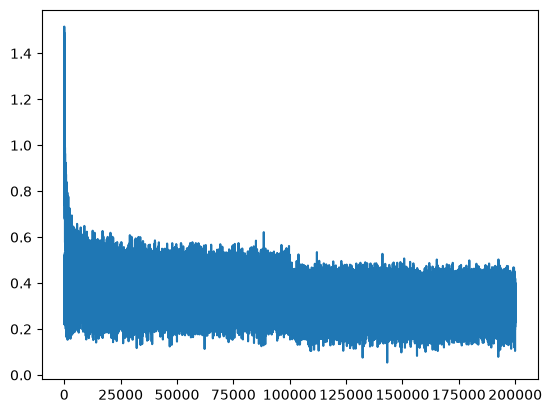

In [790]:
plt.plot(stepi, lossi)

In [791]:
emb = C[Xtr] # Full dataset
h = torch.tanh(emb.view(-1, block_size * dimensionality) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print("full train dataset loss:", loss.item())

full train dataset loss: 2.04221248626709


In [792]:
emb = C[Xdev] # Full dataset
h = torch.tanh(emb.view(-1, block_size * dimensionality) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print("full dev dataset loss:", loss.item())

full dev dataset loss: 2.1405909061431885


In [794]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out[:-1]))

carmahzato
harlin
milia
atyanna
sane
rahni
farelynn
kaqui
nellara
chaiir
kaleigh
ham
pola
quintis
lilah
jadia
wanthonielrynix
kael
dura
med
